# 16 — ESIOS reserves & balancing, disaggregated

**STATUS**: ALIVE  
**LAST-AUDIT**: 2026-05-15  
**FEEDS**: descriptive; supports the firm-level cross-market substitution hypothesis in §5 (reserve market revenue as outside option). Not a regression notebook.  
**CLAIM**: Per-BSP aFRR provision is concentrated in a handful of dominant operators; firm-level aggregation lines up with the CNMC tier. Hourly patterns differ across BSPs. Reform-window comparisons use shares (regime-invariant) because the underlying concept code (and its units) changed at ISP15.

## What is and is not disaggregated

The **only** per-BSP source ESIOS publishes for reserves is `liquicierre_all.parquet` (archives 17 + 203, aFRR settlement detail). 53.3 M rows, 34 BSPs, 32 concept codes, 2015-01 → 2026-02. We **do not** have per-BSP mFRR or RR — those are system-aggregate only. All `total*` archives (21 / 24 / 25) are also system-aggregate.

## Schema break at ISP15 (2024-11-22)

The legacy schema (`liquicierre`, 2015-01 → 2024-12-03) and the new schema (`liquicierresrs`, 2024-11-22 → present) use **different concept codes** and **different units**:

| Concept | Pre-ISP15 (`unidad = MAW`) | Post-ISP15 (`unidad = MWH`) |
|---|---|---|
| aFRR up reserve  | `RMRSP` | `EnAcSuTo` |
| aFRR down reserve | `RMRSN` | `EnAcBaTo` |
| Deviation up    | `NGDSUM` | (moved out of this archive) |
| Deviation down  | `NGDSIN` | (moved out of this archive) |

**`MAW` is an internal REE/ESIOS XML notation** — it does not appear in any of the published BOE / CNMC regulatory PDFs, so the literal expansion of the letters is uncertain. What the **BOE 2024-20995 settlement formula** (Resolución ISP15, §17.1) confirms is the operational meaning:  
> $DCRSSz = RSSz \times PMRSS$, where $RSSz$ = *Reserva de regulación secundaria a subir asignada al BSP de aFRR z* and $PMRSS$ = *Precio marginal de la reserva de regulación secundaria a subir*.  

So `RMRSP` in MAW is an **assigned reserve quantity per ISP** (15 min post-ISP15, 1 h pre), not delivered energy. `EnAcSuTo` in MWH is the **energy actually activated**. These are different objects on different time bases — not directly comparable in levels. We use **shares** (dimensionless % of total provision) for any cross-regime comparison.

## Outline

- **A** — Concentration (HHI) of aFRR-up provision, regime-aware  
- **B** — Firm-level aggregation: BSP → firm via `bsp_to_firm.csv`  
- **C** — Hourly pattern: critical vs flat hours per firm, post-ISP15 (energy activated)  
- **D** — Reform-window comparison using shares (regime-invariant)  
- **E** — Pre-ISP15 imbalance: who deviates up / down? (legacy only)


In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parents[1] if Path.cwd().name == "eda" else Path.cwd()
LIQUI = REPO / "data" / "processed" / "esios" / "reservas" / "liquicierre_all.parquet"
BSP_MAP = REPO / "data" / "external" / "esios_reference" / "bsp_to_firm.csv"

# Critical / flat hours (canonical project definition)
CRITICAL_HOURS = (5, 6, 7, 8, 16, 17, 18, 19, 20, 21, 22)
FLAT_HOURS = (1, 2, 3)

# Concept codes per regime
UP_CODES   = ["RMRSP", "EnAcSuTo"]   # pre-ISP15 + post-ISP15, aFRR up provision
DOWN_CODES = ["RMRSN", "EnAcBaTo"]

# Reform dates
ISP15 = pd.Timestamp("2024-12-09")
MTU15_IDA = pd.Timestamp("2025-03-19")
BLACKOUT = pd.Timestamp("2025-04-28")
MTU15_DA = pd.Timestamp("2025-10-01")
REFORM_LINES = [("ISP15", ISP15, "C0"), ("MTU15-IDA", MTU15_IDA, "C2"),
                ("Blackout", BLACKOUT, "k"), ("MTU15-DA", MTU15_DA, "C3")]

print(f"liquicierre: {LIQUI.stat().st_size / 1e6:.1f} MB")

liquicierre: 72.5 MB


## Data sanity

In [2]:
shape = duckdb.execute(f"""
    SELECT archive,
           MIN(date)::DATE AS d0, MAX(date)::DATE AS d1,
           COUNT(*) AS rows,
           COUNT(DISTINCT TRIM(bsp)) AS n_bsp,
           COUNT(DISTINCT info) AS n_info
    FROM '{LIQUI}'
    GROUP BY archive
""").df()
shape

,archive,d0,d1,rows,n_bsp,n_info
0,liquicierresrs,2024-11-01,2026-02-13,19031024,31,17
1,liquicierre,2015-01-01,2024-12-03,34238649,28,15


In [3]:
# Unit-tag check: are our chosen UP_CODES on the right units?
u = duckdb.execute(f"""
    SELECT archive, info, unidad_medida, COUNT(*) AS rows
    FROM '{LIQUI}'
    WHERE info IN ('RMRSP','RMRSN','EnAcSuTo','EnAcBaTo')
      AND ctd IS NOT NULL
    GROUP BY 1, 2, 3
    ORDER BY archive, info
""").df()
u

,archive,info,unidad_medida,rows
0,liquicierre,RMRSN,MAW,2815276
1,liquicierre,RMRSP,MAW,2815276
2,liquicierresrs,EnAcBaTo,MWH,1119472
3,liquicierresrs,EnAcSuTo,MWH,1119472


In [4]:
# BSP → firm mapping
bsp_map = pd.read_csv(BSP_MAP)
bsp_map["bsp"] = bsp_map["bsp"].str.strip()
print(f"BSPs mapped to firm: {bsp_map['firm'].notna().sum()} / {len(bsp_map)}")
bsp_map.head(15)

BSPs mapped to firm: 34 / 34


,bsp,firm,confidence,note
0,IMA,IB,high,Iberdrola Mercado de Aprovisionamiento (the IB...
1,IGN,IB,high,Iberdrola Generación Nuclear (Cofrentes operat...
2,IGR,IB,high,Iberdrola Generación Renovable
3,IGE,IB,medium,Iberdrola Generación Eléctrica (older naming; ...
4,IGS,IB,medium,Iberdrola Generación SA (older naming for IGE)
5,END,GE,high,Endesa Generación
6,ENC,GE,medium,Endesa Comercializadora / Endesa Carbón (subsi...
7,EV,GE,medium,Endesa Vendedora? (one of the three Endesa ret...
8,EN1,GE,medium,Endesa 1 (sub-BSP)
9,GN,GN,high,Gas Natural / Naturgy Generación


## A — Concentration (HHI), regime-aware

Each BSP's share of total aFRR-up provision in a year (using the regime-appropriate concept). HHI = sum of squared percentage shares. Highly concentrated >2500, moderate 1500–2500, competitive <1500. **Shares are dimensionless** so we can compare HHI across the regime break.

In [5]:
up_codes_sql = ", ".join(f"'{c}'" for c in UP_CODES)

df_up = duckdb.execute(f"""
    SELECT date_trunc('year', date)::DATE AS year,
           archive,
           TRIM(bsp) AS bsp,
           SUM(ctd) AS amount
    FROM '{LIQUI}'
    WHERE info IN ({up_codes_sql}) AND ctd > 0
    GROUP BY 1, 2, 3
""").df()
df_up["year"] = pd.to_datetime(df_up["year"]).dt.year

totals_year = df_up.groupby("year")["amount"].sum().rename("total")
df_up = df_up.join(totals_year, on="year")
df_up["share_pct"] = 100 * df_up["amount"] / df_up["total"]

hhi = df_up.groupby("year").apply(lambda g: (g["share_pct"] ** 2).sum())
n_bsps = df_up.groupby("year")["bsp"].nunique()
regime = df_up.groupby("year")["archive"].agg(lambda s: " + ".join(sorted(s.unique())))
pd.concat({"HHI": hhi.round(0), "N_BSPs": n_bsps, "regime": regime}, axis=1)

,HHI,N_BSPs,regime
year,,,
2015,2471.0,12,liquicierre
2016,2796.0,12,liquicierre
2017,2572.0,15,liquicierre
2018,2745.0,13,liquicierre
2019,2166.0,15,liquicierre
2020,2188.0,16,liquicierre
2021,2585.0,15,liquicierre
2022,2324.0,17,liquicierre
2023,2215.0,18,liquicierre


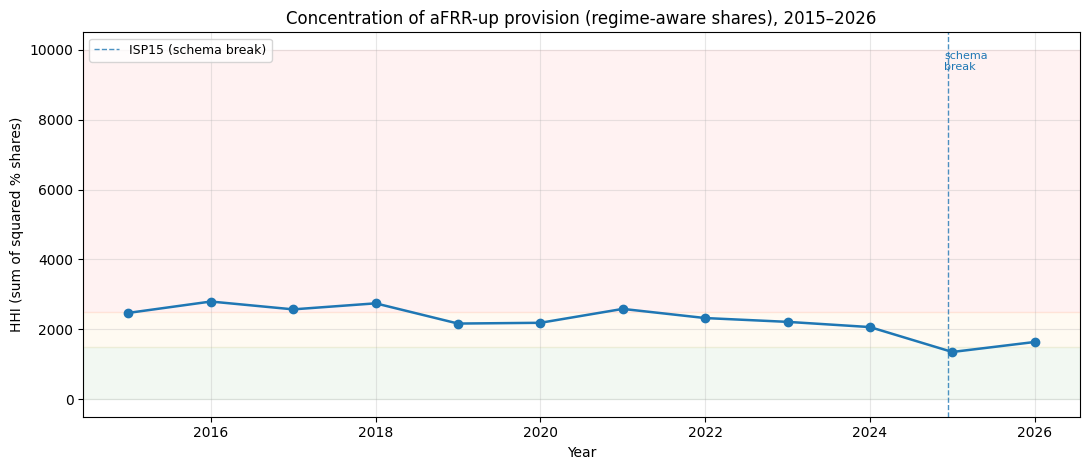

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(hhi.index, hhi.values, marker="o", linewidth=1.8, color="C0")
ax.axhspan(0, 1500, alpha=0.05, color="green")
ax.axhspan(1500, 2500, alpha=0.05, color="orange")
ax.axhspan(2500, 10000, alpha=0.05, color="red")
ax.axvline(2024 + (ISP15.dayofyear / 365.0), color="C0", linestyle="--", linewidth=1.0, alpha=0.8, label="ISP15 (schema break)")
ax.text(2024.9, ax.get_ylim()[1] * 0.95, "schema\nbreak", color="C0", fontsize=8, va="top")
ax.set_xlabel("Year")
ax.set_ylabel("HHI (sum of squared % shares)")
ax.set_title("Concentration of aFRR-up provision (regime-aware shares), 2015–2026")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
fig.tight_layout()
plt.show()

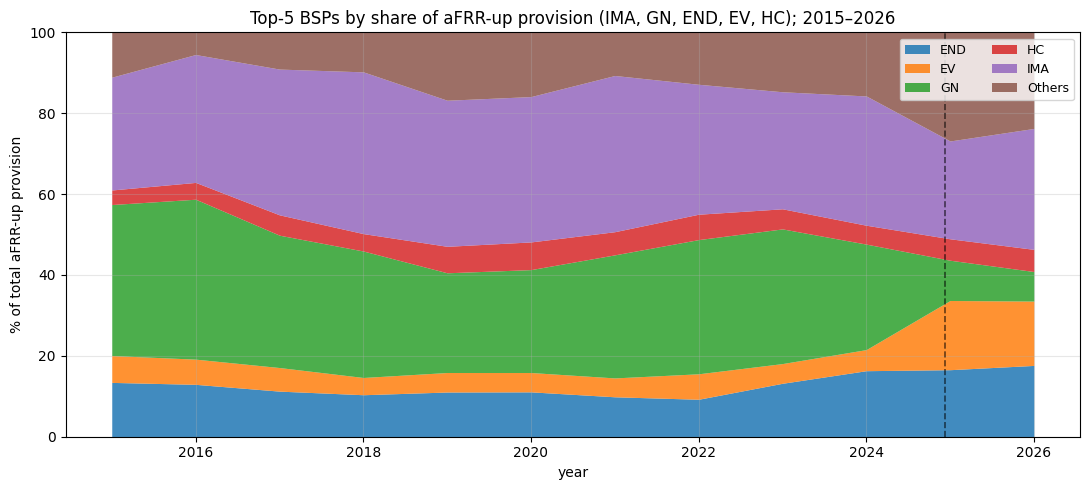

In [7]:
# Top-5 BSPs by share over time (stacked area)
top5_global = df_up.groupby("bsp")["amount"].sum().nlargest(5).index.tolist()
wide = df_up[df_up["bsp"].isin(top5_global)].pivot_table(
    index="year", columns="bsp", values="share_pct", aggfunc="sum"
).fillna(0)
wide["Others"] = (100 - wide.sum(axis=1)).clip(lower=0)

fig, ax = plt.subplots(figsize=(11, 5))
wide.plot.area(ax=ax, alpha=0.85, linewidth=0)
ax.axvline(2024 + (ISP15.dayofyear / 365.0), color="k", linestyle="--", linewidth=1.2, alpha=0.6)
ax.set_ylabel("% of total aFRR-up provision")
ax.set_title(f"Top-5 BSPs by share of aFRR-up provision ({', '.join(top5_global)}); 2015–2026")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

## B — Firm-level aggregation

Join BSPs to firms via `bsp_to_firm.csv`. BSPs without a firm (e.g. REE itself) are dropped.

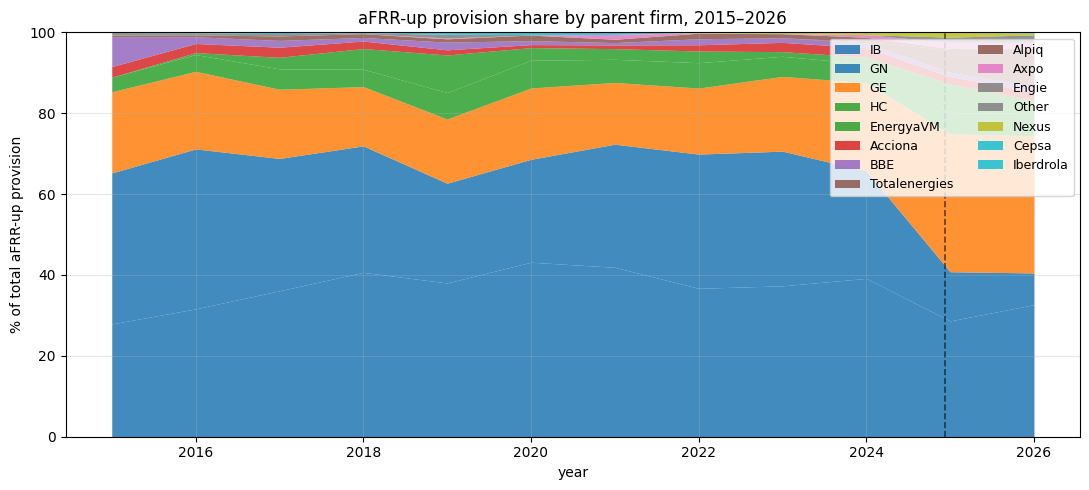

In [8]:
df_firm = df_up.merge(bsp_map[["bsp", "firm", "confidence"]], on="bsp", how="left")
df_firm = df_firm.dropna(subset=["firm"])

firm_yearly = df_firm.groupby(["year", "firm"], as_index=False)["amount"].sum()
firm_yearly["share_pct"] = firm_yearly.groupby("year")["amount"].transform(lambda s: 100 * s / s.sum())

pivot = firm_yearly.pivot(index="year", columns="firm", values="share_pct").fillna(0)
pivot = pivot[pivot.sum().sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot.area(ax=ax, alpha=0.85, linewidth=0, cmap="tab10")
ax.axvline(2024 + (ISP15.dayofyear / 365.0), color="k", linestyle="--", linewidth=1.2, alpha=0.6)
ax.set_ylabel("% of total aFRR-up provision")
ax.set_title("aFRR-up provision share by parent firm, 2015–2026")
ax.set_ylim(0, 100)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", ncol=2, fontsize=9)
fig.tight_layout()
plt.show()

In [9]:
# Firm-level HHI vs BSP-level HHI
firm_hhi = firm_yearly.groupby("year").apply(lambda g: (g["share_pct"] ** 2).sum())
n_firms = firm_yearly.groupby("year")["firm"].nunique()
pd.concat({"HHI_firm": firm_hhi.round(0), "N_firms": n_firms, "HHI_BSP": hhi.round(0)}, axis=1)

,HHI_firm,N_firms,HHI_BSP
year,,,
2015,2650.0,10,2471.0
2016,2958.0,10,2796.0
2017,2711.0,11,2572.0
2018,2895.0,10,2745.0
2019,2442.0,12,2166.0
2020,2881.0,11,2188.0
2021,2958.0,10,2585.0
2022,2769.0,11,2324.0
2023,2877.0,11,2215.0


## C — Hourly pattern (post-ISP15 energy activated)

For 2025+ (post-ISP15 only — concept code is `EnAcSuTo` here), group by hour-of-day local. Identify whether top BSPs activate disproportionately in critical or flat hours.

In [10]:
df_hr = duckdb.execute(f"""
    SELECT TRIM(bsp) AS bsp,
           EXTRACT(hour FROM (period_start_utc AT TIME ZONE 'Europe/Madrid'))::INT AS hour,
           AVG(ctd) AS mean_mwh_per_isp
    FROM '{LIQUI}'
    WHERE info = 'EnAcSuTo' AND ctd > 0
      AND date::DATE BETWEEN DATE '2025-01-01' AND DATE '2026-02-13'
    GROUP BY 1, 2
""").df()
df_hr["hour_class"] = np.where(df_hr["hour"].isin(CRITICAL_HOURS), "critical",
                                np.where(df_hr["hour"].isin(FLAT_HOURS), "flat", "midday/other"))

top_bsps = df_hr.groupby("bsp")["mean_mwh_per_isp"].sum().nlargest(8).index.tolist()
df_hr_top = df_hr[df_hr["bsp"].isin(top_bsps)]
df_hr_top.pivot_table(index="hour", columns="bsp", values="mean_mwh_per_isp").round(2)

bsp,AC2,END,EV,GN,IGR,IMA,NEX,TTE
hour,,,,,,,,
0,9.14,5.58,10.06,4.17,0.05,12.14,1.08,5.19
1,8.94,5.39,7.50,3.91,2.88,10.85,1.38,4.33
2,8.37,5.21,7.34,3.33,1.28,9.32,0.63,4.42
3,7.60,5.18,7.44,3.64,0.55,8.43,1.26,4.75
4,5.32,5.05,6.42,3.37,0.68,8.62,0.92,4.34
5,4.63,4.89,5.64,3.34,0.17,8.31,0.79,4.28
6,7.72,6.08,7.13,4.81,0.29,9.96,0.91,4.08
7,5.27,6.95,9.47,4.68,0.10,10.46,0.91,4.73
8,4.93,7.82,13.64,6.57,NaN,13.29,2.10,6.53


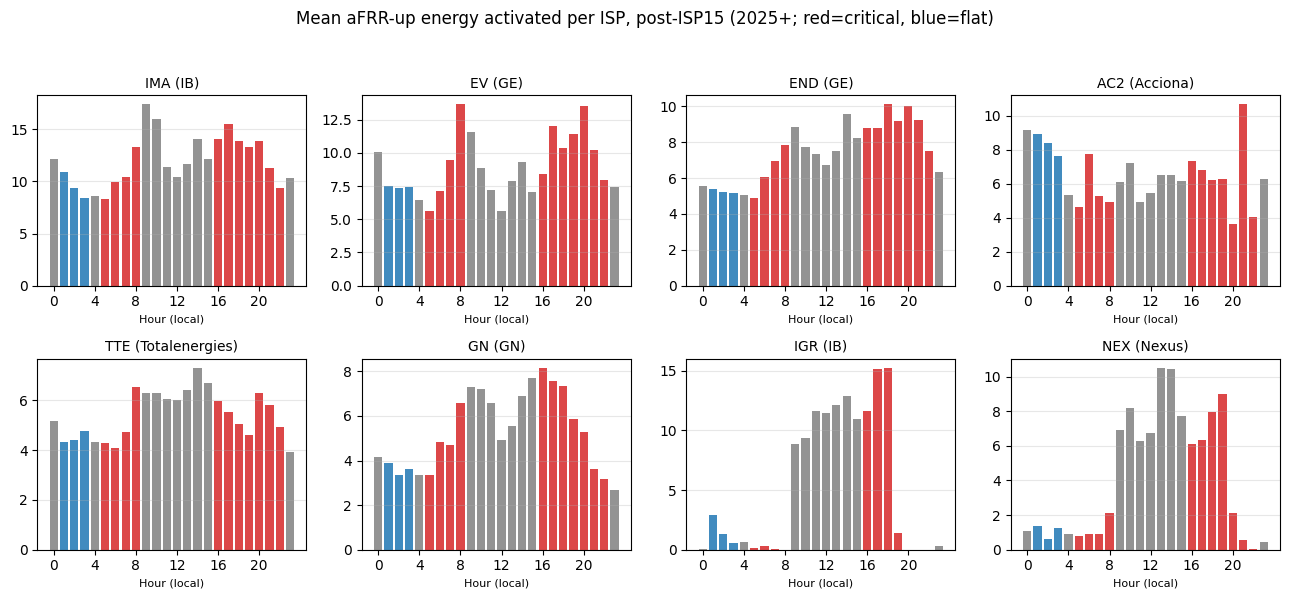

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(13, 6), sharey=False)
for ax, bsp in zip(axes.flatten(), top_bsps):
    sub = df_hr_top[df_hr_top["bsp"] == bsp].sort_values("hour")
    colors = ["C3" if h in CRITICAL_HOURS else ("C0" if h in FLAT_HOURS else "gray")
              for h in sub["hour"]]
    ax.bar(sub["hour"], sub["mean_mwh_per_isp"], color=colors, alpha=0.85)
    firm = bsp_map.set_index("bsp")["firm"].get(bsp, "?")
    ax.set_title(f"{bsp} ({firm})", fontsize=10)
    ax.set_xticks(range(0, 24, 4))
    ax.grid(alpha=0.3, axis="y")
    ax.set_xlabel("Hour (local)", fontsize=8)
fig.suptitle("Mean aFRR-up energy activated per ISP, post-ISP15 (2025+; red=critical, blue=flat)",
             fontsize=12, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## D — Reform-window comparison using shares

Compare per-firm **share** of total provision in three windows of similar length. Shares are dimensionless so we can compare across the legacy / new-schema regimes.

- **pre-ISP15**: 2024-09-01 → 2024-12-08 (concept = `RMRSP`, MAW)
- **ISP15-only**: 2024-12-09 → 2025-03-18 (concept = `EnAcSuTo`, MWh)
- **post-blackout**: 2025-04-29 → 2025-08-04 (concept = `EnAcSuTo`, MWh)

In [12]:
windows = [
    ("pre-ISP15",     "2024-09-01", "2024-12-08", "RMRSP"),
    ("ISP15-only",    "2024-12-09", "2025-03-18", "EnAcSuTo"),
    ("post-blackout", "2025-04-29", "2025-08-04", "EnAcSuTo"),
]

parts = []
for name, d0, d1, code in windows:
    r = duckdb.execute(f"""
        SELECT TRIM(bsp) AS bsp, SUM(ctd) AS amount
        FROM '{LIQUI}'
        WHERE info = '{code}' AND ctd > 0
          AND date::DATE BETWEEN DATE '{d0}' AND DATE '{d1}'
        GROUP BY 1
    """).df()
    r["window"] = name
    parts.append(r)
df_w = pd.concat(parts, ignore_index=True)
df_w = df_w.merge(bsp_map[["bsp", "firm"]], on="bsp", how="left").dropna(subset=["firm"])

firm_w = df_w.groupby(["firm", "window"], as_index=False)["amount"].sum()
firm_w["share_pct"] = firm_w.groupby("window")["amount"].transform(lambda s: 100 * s / s.sum())
pivot_w = firm_w.pivot(index="firm", columns="window", values="share_pct").fillna(0)
for col in ("pre-ISP15", "ISP15-only", "post-blackout"):
    if col not in pivot_w.columns:
        pivot_w[col] = 0.0
pivot_w = pivot_w[["pre-ISP15", "ISP15-only", "post-blackout"]]
pivot_w = pivot_w.reindex(pivot_w["post-blackout"].sort_values(ascending=False).index)
pivot_w.round(1)

window,pre-ISP15,ISP15-only,post-blackout
firm,,,
GE,19.4,28.9,32.7
IB,31.3,30.7,27.9
GN,31.7,18.6,13.5
EnergyaVM,1.2,4.2,10.1
Totalenergies,1.0,1.0,6.0
HC,6.4,8.3,4.8
Axpo,2.8,0.9,2.4
Nexus,0.5,2.3,1.2
Engie,0.0,0.1,0.8


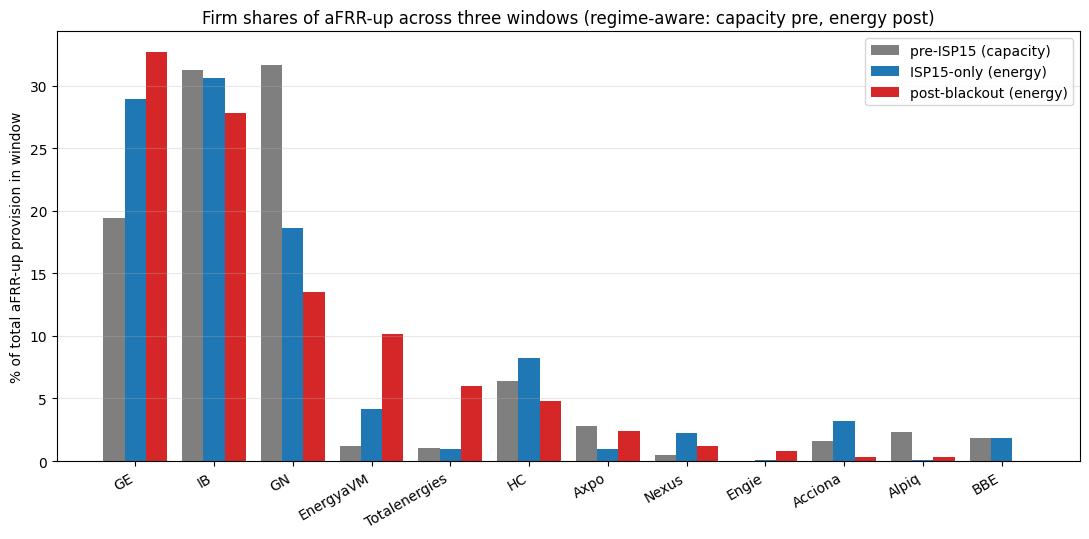

In [13]:
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(pivot_w))
w = 0.27
ax.bar(x - w, pivot_w["pre-ISP15"],     width=w, label="pre-ISP15 (capacity)",   color="C7")
ax.bar(x,     pivot_w["ISP15-only"],    width=w, label="ISP15-only (energy)",    color="C0")
ax.bar(x + w, pivot_w["post-blackout"], width=w, label="post-blackout (energy)", color="C3")
ax.set_xticks(x)
ax.set_xticklabels(pivot_w.index, rotation=30, ha="right")
ax.set_ylabel("% of total aFRR-up provision in window")
ax.set_title("Firm shares of aFRR-up across three windows (regime-aware: capacity pre, energy post)")
ax.grid(alpha=0.3, axis="y")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

## E — Pre-ISP15 imbalance: who deviates up / down?

`NGDSUM` (net generation deviation up) / `NGDSIN` (down) only exist in the legacy `liquicierre` archive (2015 → 2024-12). For each firm, the ratio `NGDSUM / NGDSIN` > 1 means tends to over-generate; < 1 means tends to under-generate.

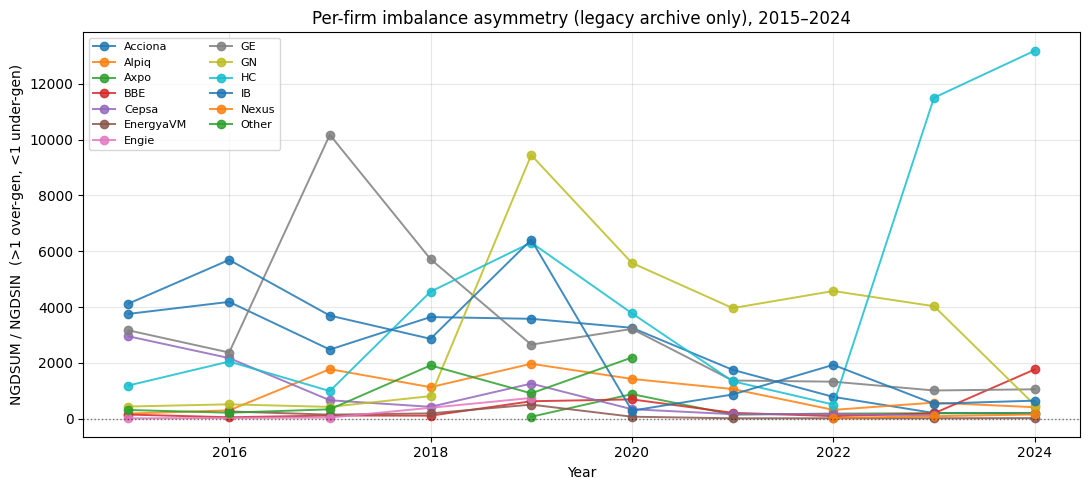

In [14]:
df_imb = duckdb.execute(f"""
    SELECT TRIM(bsp) AS bsp,
           date_trunc('year', date)::DATE AS year,
           SUM(CASE WHEN info = 'NGDSUM' THEN ctd ELSE 0 END) AS dev_up,
           SUM(CASE WHEN info = 'NGDSIN' THEN ctd ELSE 0 END) AS dev_down
    FROM '{LIQUI}'
    WHERE info IN ('NGDSUM','NGDSIN') AND ctd > 0
    GROUP BY 1, 2
""").df()
df_imb["year"] = pd.to_datetime(df_imb["year"]).dt.year
df_imb = df_imb.merge(bsp_map[["bsp", "firm"]], on="bsp", how="left").dropna(subset=["firm"])

firm_imb = df_imb.groupby(["firm", "year"], as_index=False)[["dev_up", "dev_down"]].sum()
firm_imb["asymmetry"] = firm_imb["dev_up"] / firm_imb["dev_down"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(11, 5))
for firm, g in firm_imb.groupby("firm"):
    g = g.sort_values("year")
    if g["asymmetry"].notna().sum() >= 3:
        ax.plot(g["year"], g["asymmetry"], marker="o", linewidth=1.4, label=firm, alpha=0.85)
ax.axhline(1.0, color="k", linestyle=":", linewidth=1, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("NGDSUM / NGDSIN  (>1 over-gen, <1 under-gen)")
ax.set_title("Per-firm imbalance asymmetry (legacy archive only), 2015–2024")
ax.grid(alpha=0.3)
ax.legend(loc="best", ncol=2, fontsize=8)
fig.tight_layout()
plt.show()

## F — PVPC unified-price decomposition over time

PVPC (*Precio Voluntario para el Pequeño Consumidor*) is the regulated retail tariff for small Spanish households. ESIOS publishes a 13-component decomposition (ids 805–817) of the unified price, all at 15-min native granularity, 2018-01 → 2026-05. Of the 13, the wholesale-market components matter most for our MTU15 question:

| id | component | what it captures |
|---:|---|---|
| 805 | mercado diario | DA wholesale price (the headline) |
| 808 | mercado intradiario | IDA repositioning cost |
| 806 / 807 | restricciones PBF / tiempo real | tech-restrictions cost pass-through (reforzada lives in 807) |
| 811 | banda secundaria | aFRR reserve cost |
| 812 / 813 | desvíos / saldo desvíos | imbalance pass-through |
| 810 / 814 | RPA / pagos capacidad | additional reserve + capacity payments |
| 815 / 816 | saldo P.O.14.6 / fallo nominación | small settlement balances |
| 809 | restricciones intradiario | IDA tech-restrictions |
| **817** | **PVPC final** | sum that households on the regulated tariff actually pay |


In [15]:
P_IND = REPO / "data" / "processed" / "esios" / "indicators" / "indicators_all.parquet"

PVPC_COMPONENTS = {
    805: "mercado diario",
    806: "restricciones PBF",
    807: "restricciones tiempo real (reforzada)",
    808: "mercado intradiario",
    809: "restricciones intradiario",
    810: "RPA",
    811: "banda secundaria (aFRR)",
    812: "desvíos",
    813: "saldo desvíos",
    814: "pagos capacidad",
    815: "saldo P.O.14.6",
    816: "fallo nominación UPG",
}
PVPC_FINAL_ID = 817

ids_sql = ",".join(str(i) for i in list(PVPC_COMPONENTS) + [PVPC_FINAL_ID])
pvpc = duckdb.execute(f"""
    SELECT indicator_id,
           date_trunc('month', ts_local)::DATE AS month,
           AVG(value) AS eur_mwh
    FROM '{P_IND}'
    WHERE indicator_id IN ({ids_sql}) AND geo_id IN (3, 8741)
    GROUP BY 1, 2 ORDER BY 1, 2
""").df()
pvpc["month"] = pd.to_datetime(pvpc["month"])
print(f"PVPC panel: {len(pvpc):,} (component, month) cells, "
      f"{pvpc['month'].min().date()} → {pvpc['month'].max().date()}")

PVPC panel: 1,298 (component, month) cells, 2018-01-01 → 2026-05-01


In [16]:
# Wide form for stacking: months × components
components_df = pvpc[pvpc["indicator_id"].isin(PVPC_COMPONENTS)].copy()
components_df["label"] = components_df["indicator_id"].map(PVPC_COMPONENTS)
wide = components_df.pivot(index="month", columns="label", values="eur_mwh").fillna(0)

# Order columns: wholesale-direct first, then adjustments, then small
order = [
    "mercado diario",
    "mercado intradiario",
    "restricciones PBF",
    "restricciones tiempo real (reforzada)",
    "restricciones intradiario",
    "banda secundaria (aFRR)",
    "RPA",
    "desvíos",
    "saldo desvíos",
    "pagos capacidad",
    "saldo P.O.14.6",
    "fallo nominación UPG",
]
wide = wide.reindex(columns=[c for c in order if c in wide.columns])
wide.tail(6).round(2)

label,mercado diario,mercado intradiario,restricciones PBF,restricciones tiempo real (reforzada),restricciones intradiario,banda secundaria (aFRR),RPA,desvíos,saldo desvíos,pagos capacidad,saldo P.O.14.6,fallo nominación UPG
month,,,,,,,,,,,,
2025-12-01,77.94,-0.18,11.70,1.25,0.0,1.32,0.0,0.25,-0.25,0.23,0.05,0.0
2026-01-01,71.67,-0.12,12.18,1.75,0.0,1.30,0.0,0.40,-0.63,0.21,0.05,0.0
2026-02-01,16.41,-0.17,22.05,1.40,0.0,1.16,0.0,0.39,-0.39,0.23,0.05,0.0
2026-03-01,41.77,-0.14,25.16,1.97,0.0,1.12,0.0,0.57,-0.39,0.15,0.07,0.0
2026-04-01,42.44,-0.08,18.20,2.53,0.0,1.39,0.0,0.55,-0.60,0.12,0.08,0.0
2026-05-01,56.53,-0.21,15.51,3.03,0.0,1.89,0.0,0.90,-0.75,0.09,0.06,0.0


In [17]:
fig, ax = plt.subplots(figsize=(13, 6))
# Some components can be slightly negative (settlement balances). Stacked-area requires same-sign;
# clip negatives to zero for the stacked visual and overlay the true total separately.
wide_pos = wide.clip(lower=0)
wide_pos.plot.area(ax=ax, linewidth=0, alpha=0.85, cmap="tab20")

# Overlay final price (id 817) as a line for sanity
final = pvpc[pvpc["indicator_id"] == PVPC_FINAL_ID].sort_values("month")
ax.plot(final["month"], final["eur_mwh"], color="k", linewidth=1.2, linestyle="--", label="PVPC final (id 817)")

# Reform markers
for label, date, color in REFORM_LINES:
    ax.axvline(date, color=color, linestyle=":", linewidth=0.9, alpha=0.7)
    ax.text(date, ax.get_ylim()[1] * 0.96, label, rotation=90,
            va="top", ha="right", fontsize=8, color=color, alpha=0.85)

ax.set_xlabel("Month")
ax.set_ylabel("EUR / MWh (monthly mean)")
ax.set_title("PVPC unified price — decomposition over time (12 stacked components + final dashed)")
ax.legend(loc="upper left", ncol=2, fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

/var/folders/p4/pvx6dfv509b1d3wwszsq0rqw0000gn/T/ipykernel_93866/3055710092.py:9: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(final["month"], final["eur_mwh"], color="k", linewidth=1.2, linestyle="--", label="PVPC final (id 817)")
/var/folders/p4/pvx6dfv509b1d3wwszsq0rqw0000gn/T/ipykernel_93866/3055710092.py:22: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


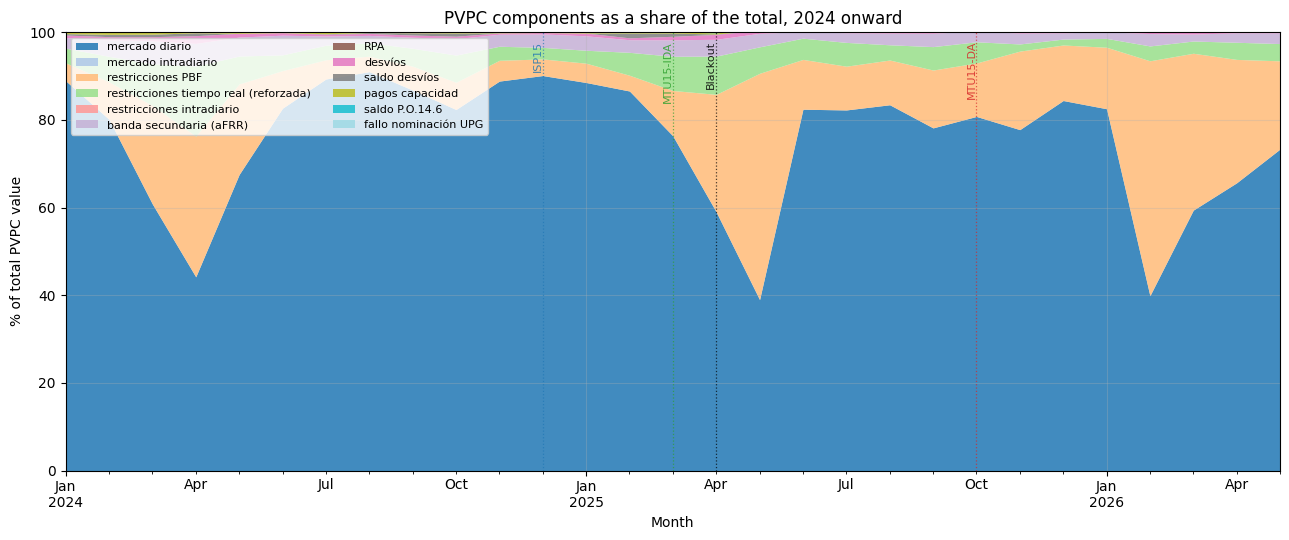

In [18]:
# Component shares of the final price, post-2024 (where MTU15 reforms hit)
denom = wide.sum(axis=1).replace(0, np.nan)
shares = (wide.div(denom, axis=0) * 100).fillna(0)
shares_2024p = shares[shares.index >= pd.Timestamp("2024-01-01")]

fig, ax = plt.subplots(figsize=(13, 5.5))
shares_2024p_pos = shares_2024p.clip(lower=0)
shares_2024p_pos.plot.area(ax=ax, linewidth=0, alpha=0.85, cmap="tab20")
for label, date, color in REFORM_LINES:
    ax.axvline(date, color=color, linestyle=":", linewidth=0.9, alpha=0.7)
    ax.text(date, 98, label, rotation=90, va="top", ha="right", fontsize=8, color=color, alpha=0.85)
ax.set_xlabel("Month")
ax.set_ylabel("% of total PVPC value")
ax.set_title("PVPC components as a share of the total, 2024 onward")
ax.set_ylim(0, 100)
ax.legend(loc="upper left", ncol=2, fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [19]:
# Reform-window contrast: average per component in three windows
windows_f = [
    ("2024 (pre-ISP15)",   "2024-01-01", "2024-11-30"),
    ("ISP15-only",         "2024-12-01", "2025-03-18"),
    ("post-MTU15-DA",      "2025-10-01", "2026-05-15"),
]
rows = []
for name, d0, d1 in windows_f:
    sub = wide[(wide.index >= d0) & (wide.index <= d1)]
    if sub.empty: continue
    means = sub.mean()
    rows.append(means.rename(name))
tab = pd.concat(rows, axis=1).round(2)
tab.loc["TOTAL (sum)"] = tab.sum()
tab

,2024 (pre-ISP15),ISP15-only,post-MTU15-DA
label,,,
mercado diario,58.50,92.33,55.16
mercado intradiario,-0.09,-0.09,-0.16
restricciones PBF,5.69,5.30,16.22
restricciones tiempo real (reforzada),3.38,4.61,2.21
restricciones intradiario,0.00,0.00,0.00
banda secundaria (aFRR),2.19,3.40,1.55
RPA,0.00,0.00,0.00
desvíos,0.41,0.55,0.46
saldo desvíos,0.20,0.44,-0.47


**Reading**. The PVPC decomposition makes two MTU15-relevant points concrete:

1. **Wholesale-component dominance**: `mercado diario` (805) is the single largest contributor to the retail price. MTU15-DA changes how this is *cleared*; the decomposition lets us trace whether the new clearing is producing a different mean wholesale price.
2. **Reforzada cost pass-through**: `restricciones tiempo real` (807) is the channel through which the post-blackout reforzada regime hits households. Its share visibly rises from April 2025 onward — visual evidence the regulatory overlay is real and continuous, complementing Figure 3 in Appendix §A.4.

Components 810 (RPA), 811 (banda secundaria aFRR), and 812/813 (desvíos) are the channels through which our **reserves & balancing** analysis (sections A–E above) reaches the retail price.

## Synthesis

_(Fill in after running. Anchor questions:)_

- Is provision concentrated in 2–3 firms (firm-HHI > 2500)?
- Does the firm-share ranking match the CNMC dominant-operator tier (Iberdrola / Endesa / Naturgy / EDP)?
- Do critical-hour BSPs differ from flat-hour BSPs in activation pattern?
- Does the post-blackout window shift the firm composition (capture-effect of reforzada)?
- Pre-ISP15 (legacy): do dominant firms systematically over- or under-generate?

## Honest caveats

1. The legacy / new-schema break at ISP15 (2024-12) means `RMRSP` (reserve-capacity assigned, ESIOS unit-tag `MAW`) and `EnAcSuTo` (energy activated, unit-tag `MWH`) measure different objects on different time bases. We use shares for cross-regime comparison; level magnitudes are not comparable. The literal expansion of `MAW` is uncertain — it does not appear in any published BOE/CNMC document, only in the settlement XML schema.
2. `bsp_to_firm.csv` is a hand-curated mapping with explicit confidence flags. Roughly 22 of 34 BSPs are high-confidence; the rest are educated guesses. Re-validate before any quantitative claim that hinges on the mapping.
3. We have no per-BSP mFRR or RR data — only system-aggregate. Cross-product substitution analyses (DA → IDA → reserves) at the firm level are aFRR-only.

_Cross-references_:
- Firm sample table in `thesis/paper/paper.tex` §3 (Iberdrola / Endesa / Naturgy / EDP-Spain / EDP-Portugal as dominant tier).
- [`memos/_esios_archive_catalog.md`](../memos/_esios_archive_catalog.md) — BSP → BRP map and ESIOS tier ordering.
- [`data/external/esios_reference/bsp_to_firm.csv`](../../data/external/esios_reference/bsp_to_firm.csv) — confidence-flagged mapping.